In [1]:
import sys, os
# switch to repo root so imports work
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
from minigrad import *
from graphviz import Digraph

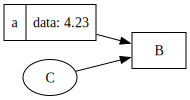

In [3]:
dot = Digraph(graph_attr={'rankdir': 'LR'})
dot.node('B', shape='record')
dot.node(name='A', label = '{a | data: 4.23}', shape='record')
dot.node('C')
dot.edge('A','B')
dot.edge('C','B')
dot

In [4]:
def trace(root):
    nodes = set()
    edges = set()

    # use DFS, DAG so keep going till all edges explored.
    nodes.add(root)
    for child in root._prev:
        edges.add((child, root))
        n, e = trace(child)
        nodes.update(n)
        edges.update(e)

    return nodes, edges


def draw_dot(root):
    dot = Digraph(
        graph_attr={'rankdir':'LR'}
    )
    
    nodes, edges = trace(root)

    for n in nodes:
        dot.node(name=str(id(n)), label="{ %s | data: %.4f | grad: %.4f}" % (n.label, n.data, n.grad), shape='record')
        # if op node, create one
        if n._op != '':
            dot.node(name = str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for a, b in edges:
        dot.edge(str(id(a)), str(id(b)) + b._op)

    return dot

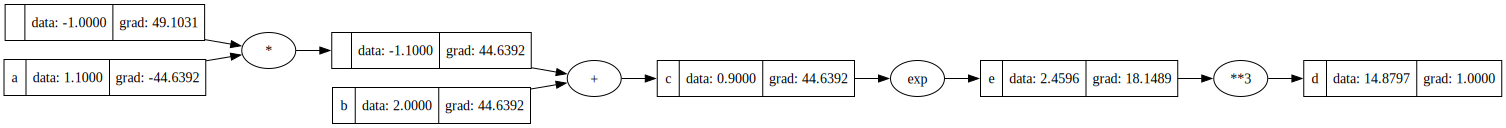

In [5]:
a = Value(1.1) ; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a ; c.label = 'c'
e = c.exp(); e.label = 'e'
d = e**3 ; d.label = 'd'

d.backward()
x = draw_dot(d)
# x.render("node_viz.png", format='png')
x

In [6]:
# testing grads
h = 0.0000001

a = Value(1.1) + h; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a; c.label = 'c'
e = c.exp(); e.label = 'e'
d1 = e**3 ; d.label = 'd'
print((d1.data - d.data) / h)

-44.639188470085855


In [7]:
from nn_tensor import MLP, Layer
import numpy as np

In [ ]:
 ## training
xs = [
    [0,0],
    [0,1],
    [1,1],
    [1,0]
]

ys = np.asarray([[1],[1],[1],[1]])

m = MLP(2, [2, 1])

In [9]:
y_preds = m(xs)
y_preds

Tensor(data=[[-1.02106461]
 [ 0.07147248]
 [-0.33678935]
 [-1.24966385]])

In [10]:
h = 0.01
loss_vals = []
params = m.parameters()
for epoch in range(10000):
    y_preds = m(xs)
    loss = y_preds - ys
    loss = (loss*loss).sum()

    loss_vals.append(loss.data)

    # remember to zero grad!
    for p in params:
        p.grad = np.zeros_like(p.grad)

    loss.backward()
    for p in params:
        p.data -= p.grad * h

    if epoch % 1000 == 0:
        print(f'epoch {epoch}, loss={loss.data}')

print(loss)
print(y_preds)

epoch 0, loss=11.794858709718781
epoch 1000, loss=0.00016504129979961335
epoch 2000, loss=0.00011400837703093548
epoch 3000, loss=7.833399470012225e-05
epoch 4000, loss=5.349517070867777e-05
epoch 5000, loss=3.630530843299411e-05
epoch 6000, loss=2.4491962406211704e-05
epoch 7000, loss=1.643157223252208e-05
epoch 8000, loss=1.0969567249742403e-05
epoch 9000, loss=7.2915987189408745e-06
Tensor(data=4.830818231167559e-06)
Tensor(data=[[0.99897173]
 [1.00118542]
 [0.99883307]
 [1.00100327]])


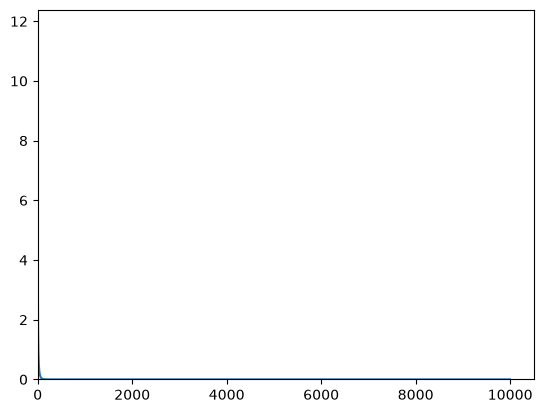

In [11]:
from matplotlib import pyplot as plt
plt.plot(loss_vals)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

In [12]:
for p in params:
    print(f"Val: {p.data}, Grad: {p.grad}")

Val: [[0.0208991  0.00388969]
 [1.00527568 0.14987663]], Grad: [[ 4.36602427e-04  8.03055325e-05]
 [ 6.40622191e-06 -3.89295288e-05]]
Val: [0.8616499  0.30901212], Grad: [-2.40198906e-05  1.41131779e-05]
Val: [[ 0.54774306]
 [-1.065434  ]], Grad: [[1.72886097e-05]
 [5.98289430e-07]]
Val: [0.93627465], Grad: [-1.3014503e-05]
